In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 69.4 MB/s eta 0:00:00


In [ ]:
from PIL import Image
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt

In [ ]:
# Add src folder to Python path
sys.path.append("../src")

In [ ]:
# Define PROJECT_DIR to ensure it's available for path construction
PROJECT_DIR = '/content/drive/MyDrive/product_search_engine'

# Construct the absolute path to the src directory
src_path = os.path.join(PROJECT_DIR, 'src')

# Add the src directory to Python's path if it's not already there
if src_path not in sys.path:
    sys.path.insert(0, src_path) # Use insert(0) to give it higher priority

Import the pipeline

In [ ]:
import importlib.util

# Redefine PROJECT_DIR and src_path for safety in this cell
PROJECT_DIR = '/content/drive/MyDrive/product_search_engine'
src_path = os.path.join(PROJECT_DIR, 'src')

# Ensure src_path is in sys.path (redundant but safe to re-insert)
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print("Current sys.path:")
for p in sys.path:
    print(p)

# Try dynamic import using importlib.util
module_name = "pipeline"
module_file_path = os.path.join(src_path, f"{module_name}.py")

# Check if the file exists before attempting to load
if not os.path.exists(module_file_path):
    print(f"Error: {module_file_path} does not exist.")
else:
    spec = importlib.util.spec_from_file_location(module_name, module_file_path)
    if spec is None:
        print(f"Error: Could not create module spec for '{module_name}' at '{module_file_path}'. This might indicate a corrupted or invalid Python file.")
    else:
        try:
            pipeline_module = importlib.util.module_from_spec(spec)
            sys.modules[module_name] = pipeline_module
            spec.loader.exec_module(pipeline_module)
            from pipeline import ProductSearchPipeline
            print("ProductSearchPipeline imported successfully.")
        except Exception as e:
            print(f"Error during module execution or class import: {e}")

Current sys.path:
/content/drive/MyDrive/product_search_engine/src
/content
/env/python
/usr/lib/python312.zip
/usr/lib/python3.12
/usr/lib/python3.12/lib-dynload

/usr/local/lib/python3.12/dist-packages
/usr/lib/python3/dist-packages
/usr/local/lib/python3.12/dist-packages/IPython/extensions
/root/.ipython
../src
ProductSearchPipeline imported successfully.


In [ ]:
# List contents of the src directory
src_files = os.listdir(src_path)
print(f"Contents of {src_path}:")
for file_name in src_files:
    print(file_name)

# Check if 'pipeline.py' is in the directory
if 'pipeline.py' in src_files:
    print("\n'pipeline.py' found in the src directory.")
else:
    print("\n'pipeline.py' NOT found in the src directory. Please check the file name and path.")

Contents of /content/drive/MyDrive/product_search_engine/src:
__pycache__
pipeline.py

'pipeline.py' found in the src directory.


In [ ]:
# pipeline = ProductSearchPipeline(f"{PROJECT_DIR}/src")
pipeline = ProductSearchPipeline(f"{PROJECT_DIR}")

In [ ]:
# Load dataset metadata
df = pd.read_csv(f"{PROJECT_DIR}/data/cleaned_products.csv")

# Get a sample image
sample_image_path = df.iloc[200]["images_path"]
print(f"sample_image_path : {sample_image_path}")

sample_image_path : /content/drive/MyDrive/product_search_engine/data/images/23623.jpg


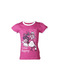

In [ ]:
# Load the image
img = Image.open(sample_image_path)
img

### Test Text Search

In [ ]:
results = pipeline.search_text(
    "black leather jacket",
    top_k=5
)

# Print raw results
print("Text Search Results:")
for idx, score in results:
    print(f"Index: {idx}, Score: {round(score, 3)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Text Search Results:
Index: 41808, Score: 6.039999961853027
Index: 720, Score: 6.039999961853027
Index: 235, Score: 6.039999961853027
Index: 21979, Score: 5.741000175476074
Index: 31815, Score: 5.585000038146973


Product Category Debugging

In [ ]:
# Debug: check detected category
query = "black leather jacket"

category = pipeline.detect_query_category(query)

print(f"Detected Category: {category}")

Detected Category: jacket


### Test Image Search

In [ ]:
indices, scores = pipeline.search_image(
    img,
    top_k=5
)

print(indices)
print(scores)

[  200  9385   621 34586 12258]
[10.680793 10.408146 10.282541 10.282118 10.24989 ]


### Test Multimodal Search

In [ ]:
results = pipeline.search_multimodal(
    text = "blue shorts",
    image = img,
    top_k = 5,
    alpha = 0.6
)

print(results)

[(np.int64(23435), np.float32(0.6)), (np.int64(200), np.float32(0.4)), (np.int64(9385), np.float32(0.1916307)), (np.int64(28909), np.float32(0.11810567)), (np.int64(16473), np.float32(0.11810567))]


In [ ]:

def show_multimodal_results(results, df):
    """
    Display images returned by multimodal search
    """

    for idx, score in results:

        img_path = df.iloc[idx]["images_path"]

        img = Image.open(img_path)

        plt.figure(figsize=(3,3))
        plt.imshow(img)
        plt.title(f"Score: {round(score, 3)}")
        plt.axis("off")

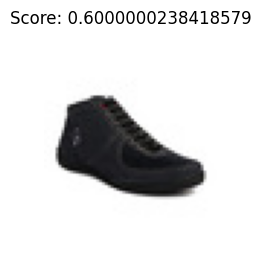

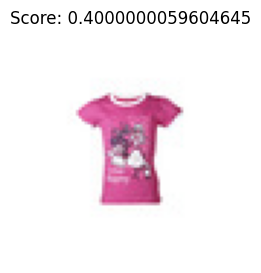

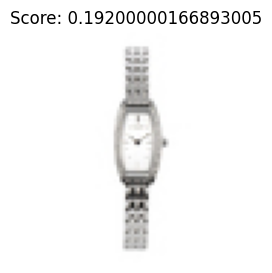

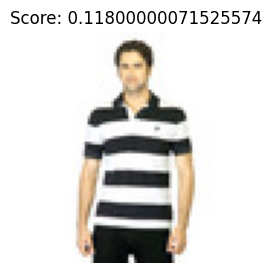

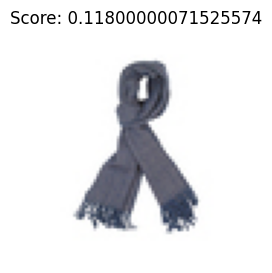

In [ ]:
show_multimodal_results(results, df)

### Comparison block between each search mode

In [ ]:
def compare_search_modes(query, img):

    print("\nTEXT SEARCH")
    text_results = pipeline.search_text(query, 5)
    show_results(text_results, df)

    print("\nIMAGE SEARCH")
    img_indices, _ = pipeline.search_image(img, 5)
    show_results([(i, 0) for i in img_indices], df)

    print("\nMULTIMODAL SEARCH")
    multi_results = pipeline.search_multimodal(query, img, 5)
    show_results(multi_results, df)

In [ ]:
compare_search_modes(query, img)


TEXT SEARCH


NameError: name 'show_results' is not defined